# Volatility Forecasting — Weekly Silver Realised Volatility

The other weekly notebooks all target the **weekly silver log-return**. Across ARIMA,
VAR, MIDAS, RF, XGBoost, and LSTM, the best WDA we have squeezed out is ≈ 0.59–0.62 on
test — roughly 60 % directional accuracy, with the simplest models often within
striking distance of the best. Return predictability for silver is, at best, weak.

**The question this chapter asks:** is **volatility** easier to forecast than direction?

Volatility clustering (Mandelbrot 1963; Engle 1982) is one of the most robust stylised
facts in financial time series — high-vol weeks cluster, low-vol weeks cluster. So even
when returns look like white noise, squared returns carry strong autocorrelation and
are forecastable. If silver vol is forecastable, that is a thesis-relevant finding (vol
forecasts feed risk management, option pricing, position sizing) even when returns are
not.

**Target** — weekly realised volatility from daily returns:

$$\text{RV}_t = \sqrt{\sum_{i \in \text{week } t} r_i^2}$$

### Notebook layout

This chapter is split the same way as the `weekly/` return notebooks — one shared
feature-build notebook, then one notebook per model, then an evaluation notebook:

| Notebook | Contents |
|---|---|
| `00_features.ipynb` (this one) | Load daily data, aggregate to weekly RV, EDA, build the HAR + EXOG feature frame, split → `volatility_weekly.csv` |
| `01_har.ipynb` | Naïve floor + HAR-RV (Corsi 2009) |
| `02_garch.ipynb` | GARCH(1,1) walk-forward |
| `03_random_forest.ipynb` | Random Forest on HAR + EXOG |
| `04_xgboost.ipynb` | XGBoost on HAR + EXOG |
| `evaluation.ipynb` | Cross-model table, sub-period breakdown, 2026 zoom, DM tests |

Every model notebook loads the single `volatility_weekly.csv` produced here, so the RV
target and feature definitions are guaranteed identical across models.

**Metrics** (defined in `src/vol_utils.py`): RMSE, MAE, $R^2$, and **DCA** —
Direction-of-Change Accuracy on $\Delta \log \text{RV}$, i.e. did the model correctly
call vol rising vs falling. DA/WDA from the return notebooks do not apply because
RV ≥ 0.


## Setup


In [1]:
import sys, os
sys.path.append(os.path.abspath('../../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
import warnings; warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.figsize'] = (10, 4)


## 1. Load daily data and aggregate to weekly RV

Same `train.csv / val.csv / test.csv` as every other weekly notebook. For each asset
the daily returns are squared, summed within each W-FRI week, then square-rooted to
give weekly realised volatility.

**Why square daily returns and sum, rather than averaging daily volatilities?**
Realised *variance* is additive — the variance contribution of each day adds up over
the week — whereas volatility (a standard deviation) is not. So we sum daily squared
returns to get the weekly realised *variance*, and take the square root only at the
end to recover weekly realised *volatility*. Summing daily volatilities directly would
have no clean statistical meaning.

In [2]:
train = pd.read_csv('../../data/processed/train.csv', parse_dates=['Date']).set_index('Date')
val   = pd.read_csv('../../data/processed/val.csv',   parse_dates=['Date']).set_index('Date')
test  = pd.read_csv('../../data/processed/test.csv',  parse_dates=['Date']).set_index('Date')

ASSETS = ['silver_return', 'gold_return', 'copper_return', 'usd_return',
          'sp500_return', 'vix_return', 'oil_return']

daily = pd.concat([train[ASSETS], val[ASSETS], test[ASSETS]]).sort_index()

def weekly_rv(daily_rets):
    """Weekly realised volatility = sqrt of the summed daily squared returns."""
    return np.sqrt((daily_rets ** 2).resample('W-FRI').sum())

rv = pd.concat({a.replace('_return', '_rv'): weekly_rv(daily[a]) for a in ASSETS}, axis=1)
rv = rv.dropna()
print(f'Weekly RV obs: {len(rv)}  ({rv.index.min().date()} -> {rv.index.max().date()})')
rv.head()


Weekly RV obs: 592  (2015-01-09 -> 2026-05-08)


,silver_rv,gold_rv,copper_rv,usd_rv,sp500_rv,vix_rv,oil_rv
Date,,,,,,,
2015-01-09,0.039710,0.021906,0.018301,0.008919,0.030649,0.203221,0.069482
2015-01-16,0.054048,0.029461,0.064370,0.004825,0.019257,0.150161,0.101212
2015-01-23,0.019898,0.015792,0.029085,0.017460,0.016872,0.158786,0.066598
2015-01-30,0.081585,0.034358,0.041376,0.010309,0.025178,0.254896,0.092746
2015-02-06,0.032449,0.026310,0.035942,0.013249,0.022479,0.172626,0.125761


## 2. EDA — autocorrelation of RV vs returns

The whole motivation for this chapter is that squared returns (and therefore RV)
should be far more autocorrelated than the signed return $r_t$ itself. If that holds
for silver, volatility is more predictable than direction.

**A note on squared returns as a variance proxy.** By definition

$$\mathbb{E}[r_t^2] = \operatorname{Var}(r_t) + \big(\mathbb{E}[r_t]\big)^2,$$

so a squared return measures variance *plus* the squared mean. At daily and weekly
horizons the conditional mean of financial returns is very close to zero, so
$\mathbb{E}[r_t] \approx 0$ and therefore
$\mathbb{E}[r_t^2] \approx \operatorname{Var}(r_t)$. Using summed squared returns as
realised variance is standard precisely under this assumption — we are implicitly
treating the short-horizon conditional mean as approximately zero, which is safe at
these frequencies where volatility dominates the mean.


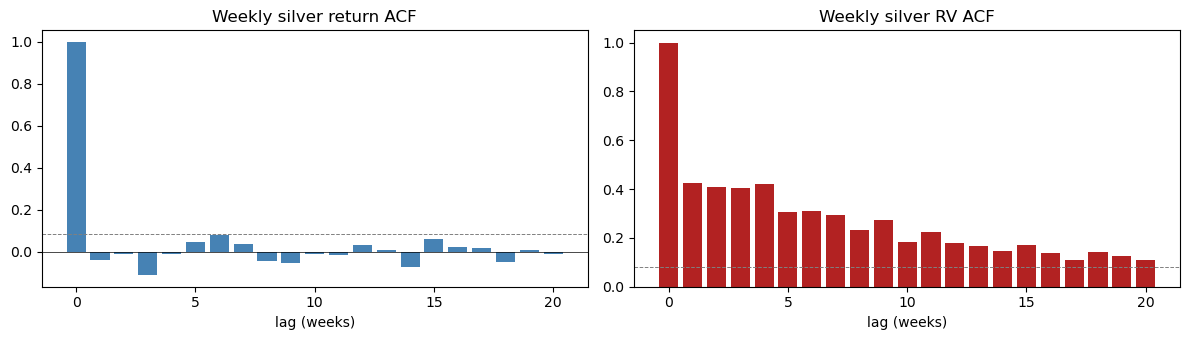

Return  ACF(1) = -0.041
RV      ACF(1) = +0.426
RV      ACF(4) = +0.422   <- multi-week persistence


In [3]:
silver_w_ret = daily['silver_return'].resample('W-FRI').sum().reindex(rv.index)
silver_rv    = rv['silver_rv']

n_lags = 20
acf_ret = acf(silver_w_ret.dropna(), nlags=n_lags, fft=True)
acf_rv  = acf(silver_rv.dropna(),    nlags=n_lags, fft=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].bar(range(len(acf_ret)), acf_ret, color='steelblue'); ax[0].set_title('Weekly silver return ACF'); ax[0].axhline(0, color='k', lw=0.5)
ax[1].bar(range(len(acf_rv)),  acf_rv,  color='firebrick'); ax[1].set_title('Weekly silver RV ACF');     ax[1].axhline(0, color='k', lw=0.5)
for a in ax: a.set_xlabel('lag (weeks)'); a.axhline(2/np.sqrt(len(silver_rv)), color='grey', ls='--', lw=0.7)
plt.tight_layout(); plt.show()

print(f'Return  ACF(1) = {acf_ret[1]:+.3f}')
print(f'RV      ACF(1) = {acf_rv[1]:+.3f}')
print(f'RV      ACF(4) = {acf_rv[4]:+.3f}   <- multi-week persistence')


## 3. HAR features + EXOG cross-asset RVs

The model-specific notebooks all draw from the same feature frame built here.

**HAR features.** The HAR-RV model (Corsi 2009 — see `01_har.ipynb` for the full model
description) regresses RV on trailing averages over several horizons. The name is short
for the *Heterogeneous Autoregressive* model of realised volatility: it assumes market
participants act on different time horizons — short-term traders react to last week,
medium-term traders to last month, longer-term traders to last quarter — so the
volatility observed today reflects all of those horizons at once. For the **weekly**
target we build three trailing averages of past RV:

- $\text{RV}^{(w)}_{t-1}$ — last week's RV (short horizon)
- $\text{RV}^{(m)}_{t-1}$ — 4-week trailing mean (≈ 1 month, medium horizon)
- $\text{RV}^{(q)}_{t-1}$ — 12-week trailing mean (≈ 1 quarter, long horizon)

All three apply `.shift(1)` first, so only information available at the end of week
$t-1$ enters the week-$t$ prediction — no intra-week look-ahead.

**EXOG features.** The tree models (`03`, `04`) additionally get 1-week lags of the
cross-asset RVs — gold, copper, USD, S&P 500, VIX, oil — to test whether volatility
spills over across asset classes. HAR-RV and GARCH stay univariate.


In [4]:
def har_features(rv_series):
    """Three HAR trailing averages of past RV (short / medium / long horizon), all lagged 1 week."""
    df = pd.DataFrame(index=rv_series.index)
    df['rv_w_lag1'] = rv_series.shift(1)
    df['rv_m_lag1'] = rv_series.shift(1).rolling(4).mean()
    df['rv_q_lag1'] = rv_series.shift(1).rolling(12).mean()
    return df

har = har_features(rv['silver_rv'])

# EXOG: 1-week lag of each cross-asset RV
exog_vol = pd.DataFrame(index=rv.index)
for c in rv.columns:
    if c == 'silver_rv':
        continue
    exog_vol[c.replace('_rv', '_rv_lag1')] = rv[c].shift(1)

# silver_ret = weekly silver log-return, kept for the GARCH notebook (it models returns, not RV)
frame = pd.concat([rv[['silver_rv']].rename(columns={'silver_rv': 'target'}),
                   har, exog_vol,
                   silver_w_ret.rename('silver_ret')], axis=1).dropna()
print(f'Modelling frame: {len(frame)} obs, {frame.shape[1]-1} columns besides target')
frame.head()


Modelling frame: 580 obs, 10 columns besides target


,target,rv_w_lag1,rv_m_lag1,rv_q_lag1,gold_rv_lag1,copper_rv_lag1,usd_rv_lag1,sp500_rv_lag1,vix_rv_lag1,oil_rv_lag1,silver_ret
Date,,,,,,,,,,,
2015-04-03,0.042182,0.010778,0.029519,0.038292,0.010026,0.021660,0.010662,0.016350,0.140043,0.084681,-0.021697
2015-04-10,0.042694,0.042182,0.033638,0.038498,0.025166,0.015996,0.011257,0.015943,0.072036,0.059034,-0.019120
2015-04-17,0.012582,0.042694,0.038844,0.037551,0.021050,0.020324,0.014129,0.010077,0.095041,0.098479,-0.009144
2015-04-24,0.028814,0.012582,0.027059,0.036942,0.011268,0.022176,0.012719,0.013421,0.157165,0.065134,-0.037051
2015-05-01,0.059376,0.028814,0.031568,0.032544,0.024591,0.033291,0.009486,0.011093,0.064794,0.040856,0.030246


### Which model uses which column

`frame` is the single source every volatility notebook draws from — each model then
picks its own subset of these columns:

| Column(s) | HAR-RV (`01`) | GARCH (`02`) | RF (`03`) | XGB (`04`) | Naïve (`01`) |
|---|:--:|:--:|:--:|:--:|:--:|
| `target` (silver RV) | predicted | predicted | predicted | predicted | predicted |
| `rv_w_lag1` | feature | — | feature | feature | **is the forecast** |
| `rv_m_lag1`, `rv_q_lag1` | feature | — | feature | feature | — |
| `*_rv_lag1` (6 EXOG cross-asset RVs) | — | — | feature | feature | — |
| `silver_ret` | — | fit input | — | — | — |

- **HAR-RV** — OLS of `target` on the three HAR lags only (`rv_w/m/q_lag1`); ignores
  EXOG and `silver_ret`.
- **GARCH(1,1)** — does *not* touch the RV features at all; it fits on the weekly
  return series `silver_ret` and uses its one-step-ahead conditional volatility as the
  RV forecast.
- **RF / XGB** — `target` on HAR + EXOG (9 features); the only models that see the
  cross-asset RV lags.
- **Naïve** — no fitting: the forecast *is* `rv_w_lag1` (= RV_{t-1}).

`rv_w_lag1` does double duty — besides being a HAR feature and the Naïve forecast, it
is the `prev_actual` baseline (RV_{t-1}) that every notebook's DCA and QLIKE-DM
evaluation measures change against. The `split` column added in §4 just labels each
row `train` / `val` / `test`; it is not a model input.

## 4. Train / val / test split and save

Matches the rest of the thesis: train ≤ 2021-12-31, val = 2022, test ≥ 2023-01-01.
The split is recorded as a `split` column so every model notebook reuses exactly the
same partition without re-deriving it.

The frame is saved to `data/processed/volatility_weekly.csv`. Columns:

- `target` — weekly silver RV (what every model predicts)
- `rv_w_lag1`, `rv_m_lag1`, `rv_q_lag1` — HAR features
- `*_rv_lag1` (gold/copper/usd/sp500/vix/oil) — EXOG cross-asset RV lags
- `silver_ret` — weekly silver log-return (used by the GARCH notebook)
- `split` — `train` / `val` / `test`


In [5]:
TR_END  = '2021-12-31'
VAL_END = '2022-12-31'

frame['split'] = 'test'
frame.loc[frame.index <= TR_END, 'split'] = 'train'
frame.loc[(frame.index > TR_END) & (frame.index <= VAL_END), 'split'] = 'val'

print(frame['split'].value_counts().reindex(['train', 'val', 'test']))

FEATS_HAR  = ['rv_w_lag1', 'rv_m_lag1', 'rv_q_lag1']
FEATS_EXOG = [c for c in frame.columns if c.endswith('_rv_lag1') and not c.startswith('silver')]
print('\nHAR  features:', FEATS_HAR)
print('EXOG features:', FEATS_EXOG)

frame.to_csv('../../data/processed/volatility_weekly.csv', index_label='Date')
print(f'\nSaved -> data/processed/volatility_weekly.csv  ({len(frame)} rows)')


split
train    353
val       52
test     175
Name: count, dtype: int64

HAR  features: ['rv_w_lag1', 'rv_m_lag1', 'rv_q_lag1']
EXOG features: ['gold_rv_lag1', 'copper_rv_lag1', 'usd_rv_lag1', 'sp500_rv_lag1', 'vix_rv_lag1', 'oil_rv_lag1']

Saved -> data/processed/volatility_weekly.csv  (580 rows)
